In [ ]:
def _bin_counts_around_stim(
    peaks_ms: dict[int, np.ndarray],
    bin_ms: float,
    stim_times_ms: np.ndarray,
    art_before_ms: float,
    art_after_ms: float,
    win_ms: tuple[float, float],
):
    """
    Bin spike counts around each stimulation event.
    """
    window_start_ms, window_end_ms = float(win_ms[0]), float(win_ms[1])

    if peaks_ms is None or len(peaks_ms) == 0:
        return None, None, None, 0

    stim_times_ms = np.asarray(stim_times_ms, float).ravel()
    if stim_times_ms.size == 0:
        return None, None, None, 0

    # Left/right edges & centers
    left_window_edges_ms: list[float] = []
    edge_value = -art_before_ms
    while edge_value >= window_start_ms:
        left_window_edges_ms.append(edge_value)
        edge_value -= bin_ms
    left_window_edges_ms = np.array(left_window_edges_ms[::-1])

    right_window_edges_ms: list[float] = []
    edge_value = art_after_ms
    while edge_value <= window_end_ms:
        right_window_edges_ms.append(edge_value)
        edge_value += bin_ms
    right_window_edges_ms = np.array(right_window_edges_ms)

    # Bin centers on each side
    left_bin_centers_ms  = (
        left_window_edges_ms[:-1] + 0.5 * bin_ms
        if left_window_edges_ms.size > 1 else np.array([], float)
    )
    right_bin_centers_ms = (
        right_window_edges_ms[:-1] + 0.5 * bin_ms
        if right_window_edges_ms.size > 1 else np.array([], float)
    )

    bin_edges_ms   = np.concatenate([left_window_edges_ms, right_window_edges_ms])
    bin_centers_ms = np.concatenate([left_bin_centers_ms, right_bin_centers_ms])
    n_bins         = bin_centers_ms.size

    # Number of bins on the left side (used to offset right-side indices)
    n_left_bins = max(left_window_edges_ms.size - 1, 0)

    n_trials    = len(stim_times_ms)
    ch_keys = sorted(peaks_ms.keys())
    n_channels = len(ch_keys)

    # counts[trial_index, channel_index, bin_index]
    counts = np.zeros((n_trials, n_channels, n_bins), float)

    # Binning
    for trial_index, stim_time_ms in enumerate(stim_times_ms):
        trial_window_start_ms = stim_time_ms + window_start_ms
        trial_window_end_ms   = stim_time_ms + window_end_ms
        for ch_i, ch_id in enumerate(ch_keys):
            spike_times_ms = np.asarray(peaks_ms[ch_id], float).ravel()
            if spike_times_ms.size == 0:
                continue

            # Spikes within the overall peri-stim window (absolute)
            in_window_mask = (
                (spike_times_ms >= trial_window_start_ms) &
                (spike_times_ms <= trial_window_end_ms)
            )
            if not in_window_mask.any():
                continue

            # Relative spike times in ms, centered at the stim
            spike_times_rel_ms = spike_times_ms[in_window_mask] - stim_time_ms

            # Exclude spikes in the artifact gap [-art_before_ms, +art_after_ms]
            left_side_mask  = (
                (spike_times_rel_ms >= window_start_ms) &
                (spike_times_rel_ms < -art_before_ms)
            )
            right_side_mask = (
                (spike_times_rel_ms > art_after_ms) &
                (spike_times_rel_ms <= window_end_ms)
            )

            # ---- LEFT side binning ----
            if left_window_edges_ms.size > 1 and left_side_mask.any():
                spike_times_left_ms = spike_times_rel_ms[left_side_mask]
                # Find bin index j such that edges[j] <= t < edges[j+1]
                left_bin_indices = np.searchsorted(
                    left_window_edges_ms, spike_times_left_ms, side="right"
                ) - 1
                valid_left_bins = (
                    (left_bin_indices >= 0) &
                    (left_bin_indices < left_window_edges_ms.size - 1)
                )
                if valid_left_bins.any():
                    np.add.at(counts[trial_index, ch_i], left_bin_indices[valid_left_bins], 1.0)

            # ---- RIGHT side binning ----
            if right_window_edges_ms.size > 1 and right_side_mask.any():
                spike_times_right_ms = spike_times_rel_ms[right_side_mask]
                right_bin_indices_local = np.searchsorted(
                    right_window_edges_ms, spike_times_right_ms, side="right"
                ) - 1
                valid_right_bins = (
                    (right_bin_indices_local >= 0) &
                    (right_bin_indices_local < right_window_edges_ms.size - 1)
                )
                if valid_right_bins.any():
                    # Map right-side bins into global bin indices
                    right_bin_indices_global = (
                        right_bin_indices_local[valid_right_bins] + n_left_bins
                    )
                    np.add.at(counts[trial_index, ch_i], right_bin_indices_global, 1.0)
    return counts, bin_centers_ms, bin_edges_ms, n_left_bins

def _smooth_segment(seg_counts, seg_edges, seg_centers, sigma_ms):
        """
        """
        L = seg_centers.size
        if L == 0 or sigma_ms <= 0:
            return seg_counts.copy()

        # bin widths
        dt_ms = np.diff(seg_edges)
        dt_sec = np.clip(dt_ms / 1000.0, 1e-12, None)

        # convert counts → rates
        rates = seg_counts / dt_sec[None, None, :]   # broadcast dt

        # Gaussian weights
        diff = seg_centers[:, None] - seg_centers[None, :]
        W = np.exp(-(diff**2) / (2.0 * sigma_ms**2))   # (L, L)

        # output
        out = np.full_like(rates, np.nan)

        for tr in range(rates.shape[0]):
            for ch in range(rates.shape[1]):
                r = rates[tr, ch]
                valid = np.isfinite(r)
                if not valid.any():
                    continue

                r_valid = np.where(valid, r, 0.0)
                num = r_valid @ W.T
                den = (valid.astype(float) @ W.T).clip(1e-12, None)
                out[tr, ch] = num / den

        return out

def _smooth_counts_gauss(
    counts: np.ndarray,
    edges: np.ndarray,
    bin_centers_ms: np.ndarray,
    sigma_ms: float,
    left_bins: int,
) -> np.ndarray:
    """
    Smooth spike counts -> firing rates (Hz) separately on left and right sides
    of the stim-blank gap, using a Gaussian in ms (NaN-aware at the per-bin level).
    """
    if counts is None or np.size(counts) == 0:
        return np.asarray(counts, float)

    gap_bin = int(left_bins)
    gap_bin = max(0, min(gap_bin, counts.shape[-1]))  # clamp

    left_counts   = counts[:, :, :gap_bin]
    right_counts  = counts[:, :, gap_bin:]
    left_centers  = bin_centers_ms[:gap_bin]
    right_centers = bin_centers_ms[gap_bin:]

    # edges is length (T+2): left edges (L+1) + right edges (R+1)
    left_edges  = edges[:gap_bin + 1]
    right_edges = edges[gap_bin + 1:]

    left_sm  = _smooth_segment(left_counts,  left_edges,  left_centers,  sigma_ms)
    right_sm = _smooth_segment(right_counts, right_edges, right_centers, sigma_ms)

    out = np.full_like(counts, np.nan, dtype=float)
    out[:, :, :gap_bin] = left_sm
    out[:, :, gap_bin:] = right_sm
    return out


0.0 334.9877240895917


/tmp/ipykernel_1217019/1903450849.py:34: RuntimeWarning: Mean of empty slice
  plt.plot(t_ms, np.nanmean(spikes[:, ch_select, :], axis = 0), color="red")


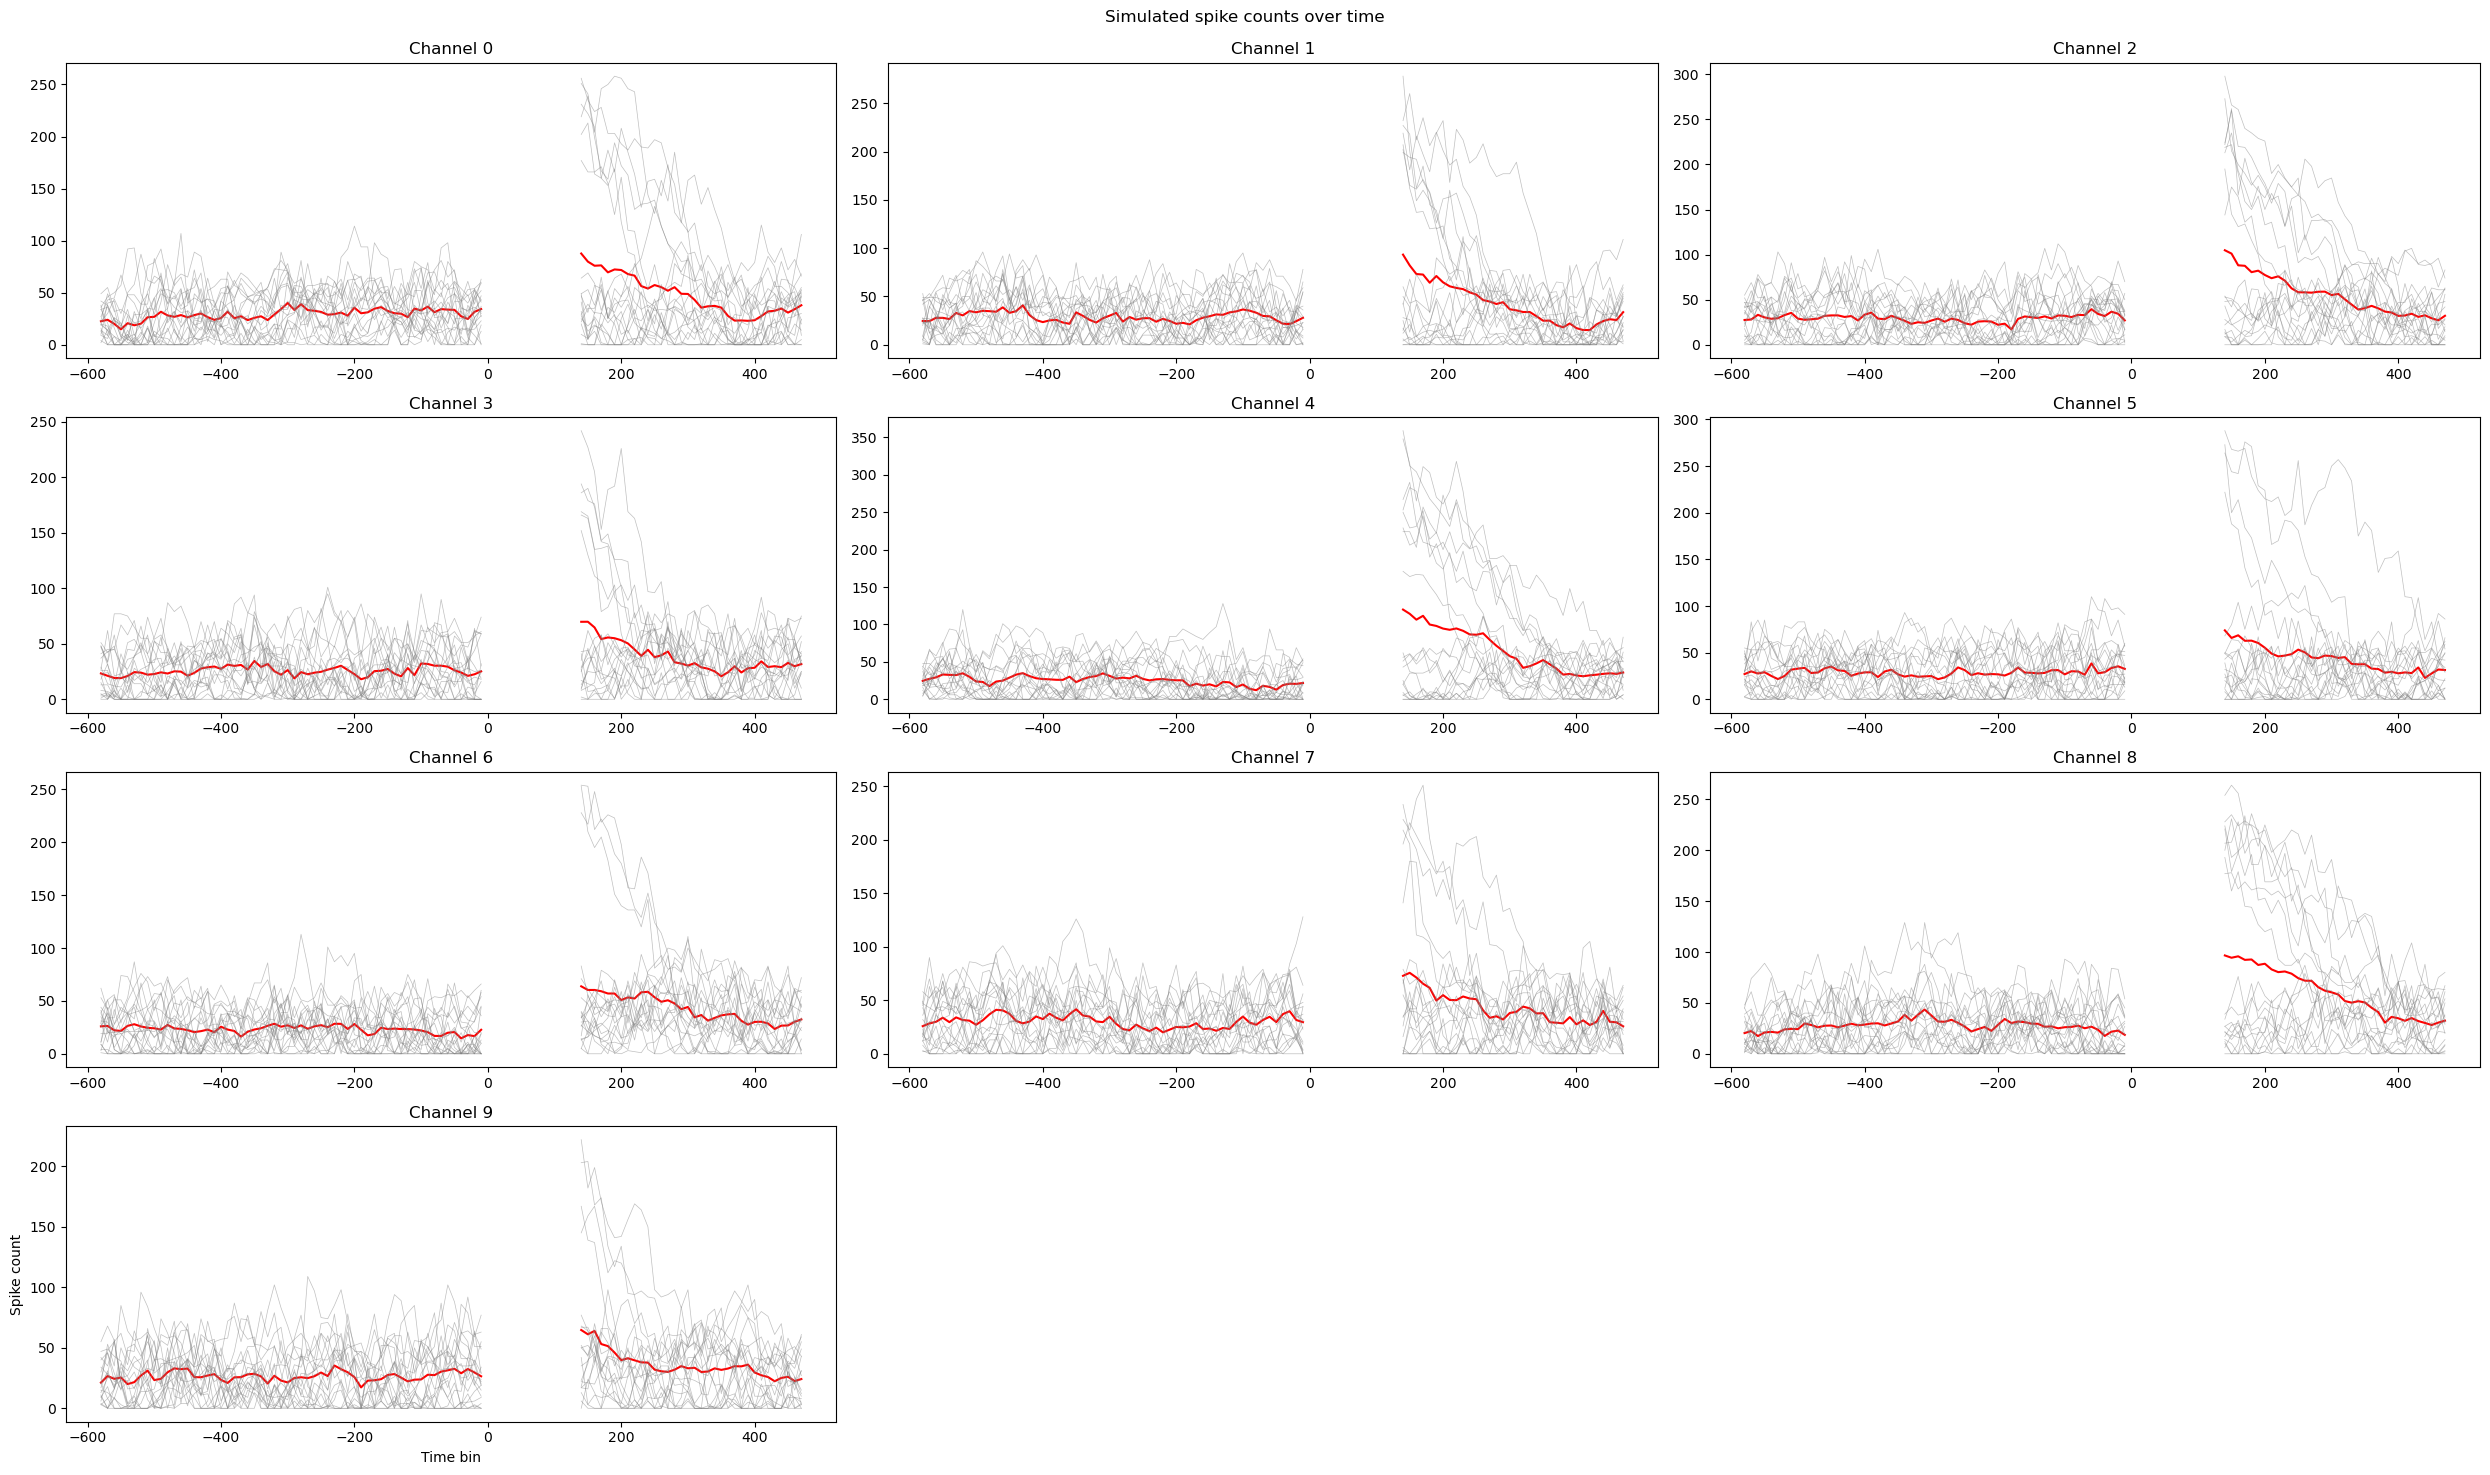

In [6]:
from wasabi.data_simulation import DataSimulation
import matplotlib.pyplot as plt
import numpy as np

n_trials = 20
n_ch = 128
n_bins = 106
n_stim = 32
onset_time = 58
stim_effect = 200
base_rate = 25
rw_sigma = 15
rate_max = 50
stim_dur_bins = 14

sim = DataSimulation(n_trials, n_ch, n_bins, n_stim, onset_time, stim_effect, base_rate, rw_sigma, rate_max, stim_dur_bins)

stim_mask = sim.generate_stim_trials()
rates = sim.generate_rates(add_stim=True)
spikes = sim.poisson_spikes(rates)

print(np.nanmin(rates), np.nanmax(rates))

bin_ms = 10
t_ms = (np.arange(n_bins) - onset_time) * bin_ms

plt.figure(figsize=(25, 15))
for ch_select in range(10):
    ax = plt.subplot(4, 3, ch_select + 1)

    # trials x time for this channel
    y = spikes[:, ch_select, :]  # (n_trials, n_bins)

    plt.plot(t_ms, np.nanmean(spikes[:, ch_select, :], axis = 0), color="red")
    plt.plot(t_ms, spikes[:, ch_select, :].T, color="gray", linewidth=0.5, alpha=0.5)

    plt.title(f"Channel {ch_select}")

plt.suptitle("Simulated spike counts over time\n")
plt.xlabel("Time bin")
plt.ylabel("Spike count")
plt.tight_layout()

In [ ]:
spikes.shape

(20, 128, 106)